# Pixel-wise MNIST: `ParaGRU` vs normal `torch.nn.GRU`

This notebook is a clean beginner-friendly demo of the PyTorch-like API:

```python
from src.pararnn import ParaGRU, ParaGRUCell
```

We compare three GPU-based GRU models on the same pixel-wise MNIST task:

1. **ParaGRU sequential**: uses this repo's `ParaGRU` in ordinary sequential mode.
2. **ParaGRU quasi-DEER `accel_scan`**: uses this repo's accelerated quasi-DEER mode.
3. **Normal GPU GRU**: uses PyTorch's built-in `torch.nn.GRU`.

Each MNIST image is treated as one long sequence of pixels.

A normal MNIST image has shape:

$$
x \in \mathbb{R}^{28 \times 28}
$$

For pixel-wise MNIST, we flatten it into:

$$
x \in \mathbb{R}^{784 \times 1}
$$

That means:

* sequence length: $T = 28 \times 28 = 784$
* input size per time step: $1$
* hidden size: chosen by us, for example $128$

So one image is read pixel by pixel:

```text
pixel 1   -> GRU
pixel 2   -> GRU
...
pixel 784 -> GRU
```

After all 784 pixels are processed, the final hidden state is passed to a linear classifier:

$$
h_T \rightarrow \text{Linear} \rightarrow \text{class logits}
$$

The classifier predicts one of the ten MNIST digit classes:

$$
0, 1, 2, \dots, 9
$$

## 1. Imports and project path

In [1]:
from pathlib import Path
import sys

# If this notebook is inside Parallel-RNN/notebooks, then the repo root is one level up.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/cpt/Documents/Github/Parallel-RNN


In [2]:
import importlib.util
import time
from dataclasses import dataclass

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from src.pararnn import ParaGRU, ParaGRUCell

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "This notebook is configured for a GPU comparison with accel_scan. "
        "Please run it on a CUDA machine."
    )

if importlib.util.find_spec("accelerated_scan.warp") is None:
    raise RuntimeError(
        "This notebook uses scan_backend='accel_scan', but accelerated_scan.warp "
        "is not installed in this environment."
    )

device = torch.device("cuda")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(device))


Torch version: 2.12.0+cu130
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


## 2. Configuration

For a quick demo, we train on a subset by default.

Increase `TRAIN_SAMPLES`, `TEST_SAMPLES`, or `EPOCHS` after the notebook works.

To keep the comparison fair, all three models use the same data, hidden size, batch size, optimizer settings, and number of epochs.

The accelerated ParaGRU run uses:

```python
scan_backend = "accel_scan"
num_iters = 8
```

The sequential ParaGRU run uses normal sequential recurrence instead.


In [3]:
@dataclass
class Config:
    seed: int = 0

    # MNIST pixel-wise sequence settings
    input_size: int = 1
    sequence_length: int = 28 * 28
    image_height: int = 28
    image_width: int = 28
    num_classes: int = 10

    # Shared model settings
    hidden_size: int = 128

    # ParaGRU quasi-DEER acceleration settings
    deer_backend: str = "adjoint"
    deer_scan_backend: str = "accel_scan"
    deer_num_iters: int = 8

    # Training settings
    batch_size: int = 128
    epochs: int = 10
    learning_rate: float = 3e-3
    weight_decay: float = 1e-4

    # Demo subset sizes
    use_subset: bool = True
    train_samples: int = 10_000
    test_samples: int = 2_000

    # DataLoader
    num_workers: int = 2


cfg = Config()
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

cfg


Config(seed=0, input_size=1, sequence_length=784, image_height=28, image_width=28, num_classes=10, hidden_size=128, deer_backend='adjoint', deer_scan_backend='accel_scan', deer_num_iters=8, batch_size=128, epochs=10, learning_rate=0.003, weight_decay=0.0001, use_subset=True, train_samples=10000, test_samples=2000, num_workers=2)

## 3. Load MNIST

`torchvision.datasets.MNIST` returns each image as shape:

```text
(1, 28, 28)
```

We flatten the whole image into one pixel sequence:

```text
(1, 28, 28) -> (784, 1)
```

So each batch has shape:

```text
(batch, 784, 1)
```

That is exactly what `ParaGRU(input_size=1, batch_first=True)` expects.


In [4]:
data_dir = PROJECT_ROOT / "notebooks" / "data"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda image: image.reshape(cfg.sequence_length, cfg.input_size)),
])

train_dataset_full = datasets.MNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform,
)

test_dataset_full = datasets.MNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform,
)

if cfg.use_subset:
    train_dataset = Subset(train_dataset_full, range(cfg.train_samples))
    test_dataset = Subset(test_dataset_full, range(cfg.test_samples))
else:
    train_dataset = train_dataset_full
    test_dataset = test_dataset_full

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

x_batch, y_batch = next(iter(train_loader))

print("x_batch shape:", tuple(x_batch.shape))
print("y_batch shape:", tuple(y_batch.shape))
print("x dtype:", x_batch.dtype)
print("labels:", y_batch[:10].tolist())


100%|██████████| 9.91M/9.91M [00:16<00:00, 616kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 141kB/s]
100%|██████████| 1.65M/1.65M [00:11<00:00, 139kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]


x_batch shape: (128, 784, 1)
y_batch shape: (128,)
x dtype: torch.float32
labels: [3, 9, 1, 0, 9, 9, 1, 8, 9, 1]


## 4. Define three simple models

All three models have the same outer shape:

```python
RNN -> Linear head
```

The difference is the recurrent layer:

- `ParaGRU sequential` uses `ParaGRU(mode="sequential")`.
- `ParaGRU quasi-DEER accel_scan` uses `ParaGRU(mode="deer", scan_backend="accel_scan")`.
- `Torch GRU` uses PyTorch's normal `nn.GRU`.

For classification, all models use the final hidden state.


In [5]:
class PixelMNISTParaGRUClassifier(nn.Module):
    def __init__(
        self,
        cfg: Config,
        *,
        mode: str,
        backend: str = "autograd",
        scan_backend: str = "torch",
        num_iters: int = 4,
    ):
        super().__init__()

        self.rnn = ParaGRU(
            input_size=cfg.input_size,
            hidden_size=cfg.hidden_size,
            batch_first=True,
            mode=mode,
            backend=backend,
            scan_backend=scan_backend,
            num_iters=num_iters,
            tol=1e-4,
            strict_tol=False,
            dtype=torch.float32,
            recurrent_init_scale=0.08,
        )
        self.head = nn.Linear(cfg.hidden_size, cfg.num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, h_n = self.rnn(x)
        final_hidden = h_n[-1]
        return self.head(final_hidden)


class PixelMNISTTorchGRUClassifier(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()

        self.rnn = nn.GRU(
            input_size=cfg.input_size,
            hidden_size=cfg.hidden_size,
            batch_first=True,
        )
        self.head = nn.Linear(cfg.hidden_size, cfg.num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, h_n = self.rnn(x)
        final_hidden = h_n[-1]
        return self.head(final_hidden)


def make_paragru_sequential(cfg: Config) -> nn.Module:
    return PixelMNISTParaGRUClassifier(
        cfg,
        mode="sequential",
        backend="autograd",
        scan_backend="torch",
        num_iters=1,
    )


def make_paragru_quasi_deer_accel(cfg: Config) -> nn.Module:
    return PixelMNISTParaGRUClassifier(
        cfg,
        mode="deer",
        backend=cfg.deer_backend,
        scan_backend=cfg.deer_scan_backend,
        num_iters=cfg.deer_num_iters,
    )


def make_torch_gru(cfg: Config) -> nn.Module:
    return PixelMNISTTorchGRUClassifier(cfg)


criterion = nn.CrossEntropyLoss()

models_to_run = {
    "ParaGRU sequential": make_paragru_sequential,
    "ParaGRU quasi-DEER accel_scan": make_paragru_quasi_deer_accel,
    "Torch GRU": make_torch_gru,
}

print("Models to compare:")
for model_name in models_to_run:
    print("-", model_name)


Models to compare:
- ParaGRU sequential
- ParaGRU quasi-DEER accel_scan
- Torch GRU


## 5. One forward/backward sanity check

Before training, we check that all three models:

1. produce logits,
2. produce a finite loss,
3. compute gradients with `loss.backward()`.


In [6]:
x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device, non_blocking=True)
y_batch = y_batch.to(device, non_blocking=True)

for model_name, make_model in models_to_run.items():
    torch.manual_seed(cfg.seed)
    model = make_model(cfg).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    model.train()
    optimizer.zero_grad(set_to_none=True)

    logits = model(x_batch)
    loss = criterion(logits, y_batch)
    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    print(f"{model_name}")
    print("  logits shape:", tuple(logits.shape))
    print("  loss:", float(loss.detach().cpu()))
    print("  grad norm:", float(grad_norm.detach().cpu() if torch.is_tensor(grad_norm) else grad_norm))

    del model, optimizer

if device.type == "cuda":
    torch.cuda.empty_cache()


ParaGRU sequential
  logits shape: (128, 10)
  loss: 2.30765700340271
  grad norm: 0.1452832967042923
ninja: no work to do.
ParaGRU quasi-DEER accel_scan
  logits shape: (128, 10)
  loss: 2.30765700340271
  grad norm: 0.1452832967042923
Torch GRU
  logits shape: (128, 10)
  loss: 2.311981678009033
  grad norm: 0.1907677799463272


## 6. Training and evaluation functions

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    start_time = time.perf_counter()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = y.numel()
        total_loss += float(loss.detach().cpu()) * batch_size
        total_correct += int((logits.argmax(dim=-1) == y).sum().detach().cpu())
        total_count += batch_size

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start_time

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
        "seconds": elapsed,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = y.numel()
        total_loss += float(loss.detach().cpu()) * batch_size
        total_correct += int((logits.argmax(dim=-1) == y).sum().detach().cpu())
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
    }

## 7. Train all three models

The first epoch may be slower because CUDA kernels and internal PyTorch paths warm up.

We train the models one after the other and save:

- training accuracy,
- test accuracy,
- elapsed training time per epoch.


In [8]:
def make_optimizer(model, cfg):
    return torch.optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )


def run_experiment(model_name, make_model, cfg):
    print(f"\n=== {model_name} ===")

    torch.manual_seed(cfg.seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(cfg.seed)
        torch.cuda.reset_peak_memory_stats(device)

    model = make_model(cfg).to(device)
    optimizer = make_optimizer(model, cfg)
    history = []

    for epoch in range(1, cfg.epochs + 1):
        train_metrics = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )
        test_metrics = evaluate(
            model=model,
            loader=test_loader,
            criterion=criterion,
            device=device,
        )

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "seconds": train_metrics["seconds"],
        }
        history.append(row)

        print(
            f"epoch={epoch:02d} "
            f"train_acc={row['train_accuracy']:.4f} "
            f"test_acc={row['test_accuracy']:.4f} "
            f"seconds={row['seconds']:.2f}"
        )

    peak_mb = None
    if device.type == "cuda":
        peak_mb = torch.cuda.max_memory_allocated(device) / 1024**2
        print(f"Peak CUDA memory allocated: {peak_mb:.2f} MB")

    return model, history, peak_mb


trained_models = {}
all_histories = {}
peak_memory_mb = {}

for model_name, make_model in models_to_run.items():
    model, history, peak_mb = run_experiment(model_name, make_model, cfg)
    trained_models[model_name] = model
    all_histories[model_name] = history
    peak_memory_mb[model_name] = peak_mb



=== ParaGRU sequential ===
epoch=01 train_acc=0.1058 test_acc=0.1170 seconds=41.57
epoch=02 train_acc=0.1100 test_acc=0.1170 seconds=38.92
epoch=03 train_acc=0.1129 test_acc=0.1175 seconds=39.38
epoch=04 train_acc=0.1108 test_acc=0.1170 seconds=38.77
epoch=05 train_acc=0.1133 test_acc=0.1230 seconds=39.45
epoch=06 train_acc=0.1433 test_acc=0.2035 seconds=38.78
epoch=07 train_acc=0.2729 test_acc=0.2830 seconds=38.94
epoch=08 train_acc=0.3925 test_acc=0.3770 seconds=39.15
epoch=09 train_acc=0.4323 test_acc=0.3920 seconds=39.25
epoch=10 train_acc=0.4380 test_acc=0.4185 seconds=38.89
Peak CUDA memory allocated: 361.77 MB

=== ParaGRU quasi-DEER accel_scan ===
epoch=01 train_acc=0.1058 test_acc=0.1170 seconds=11.00
epoch=02 train_acc=0.1100 test_acc=0.1170 seconds=11.12
epoch=03 train_acc=0.1129 test_acc=0.1175 seconds=11.18
epoch=04 train_acc=0.1108 test_acc=0.1170 seconds=12.75
epoch=05 train_acc=0.1133 test_acc=0.1230 seconds=13.75
epoch=06 train_acc=0.1433 test_acc=0.2035 seconds=16.52

## 8. Compare accuracy and elapsed time

The table below compares the final test accuracy and total training time.

Model comparison
----------------
ParaGRU sequential | test accuracy: 0.4185 | train time: 393.10s | peak memory: 361.8 MB
ParaGRU quasi-DEER accel_scan | test accuracy: 0.4170 | train time: 156.64s | peak memory: 1577.7 MB
Torch GRU          | test accuracy: 0.0875 | train time: 15.43s | peak memory: 1355.0 MB


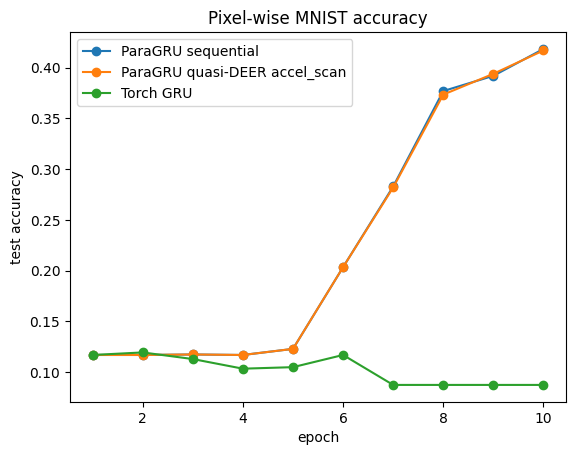

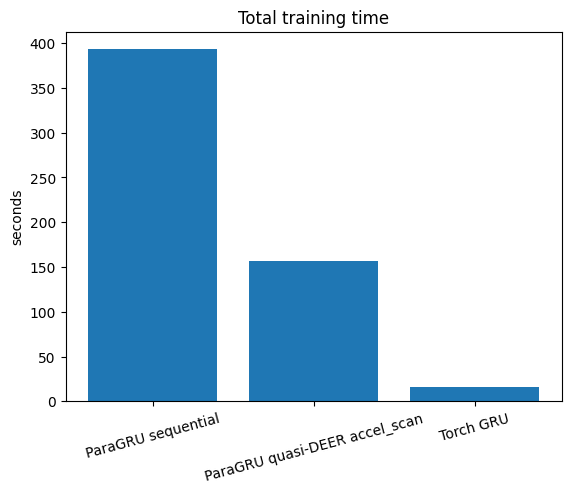

In [9]:
import matplotlib.pyplot as plt

summary = []

for model_name, history in all_histories.items():
    final_row = history[-1]
    total_seconds = sum(row["seconds"] for row in history)

    summary.append({
        "model": model_name,
        "final_test_accuracy": final_row["test_accuracy"],
        "total_train_seconds": total_seconds,
        "peak_cuda_memory_mb": peak_memory_mb[model_name],
    })

print("Model comparison")
print("----------------")
for row in summary:
    memory_text = "n/a" if row["peak_cuda_memory_mb"] is None else f"{row['peak_cuda_memory_mb']:.1f} MB"
    print(
        f"{row['model']:18s} | "
        f"test accuracy: {row['final_test_accuracy']:.4f} | "
        f"train time: {row['total_train_seconds']:.2f}s | "
        f"peak memory: {memory_text}"
    )

plt.figure()
for model_name, history in all_histories.items():
    epochs = [row["epoch"] for row in history]
    test_accs = [row["test_accuracy"] for row in history]
    plt.plot(epochs, test_accs, marker="o", label=model_name)

plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.title("Pixel-wise MNIST accuracy")
plt.legend()
plt.show()

plt.figure()
model_names = [row["model"] for row in summary]
times = [row["total_train_seconds"] for row in summary]
plt.bar(model_names, times)
plt.ylabel("seconds")
plt.title("Total training time")
plt.xticks(rotation=15)
plt.show()


## 9. Inspect predictions

This cell shows a few predictions from one trained model.

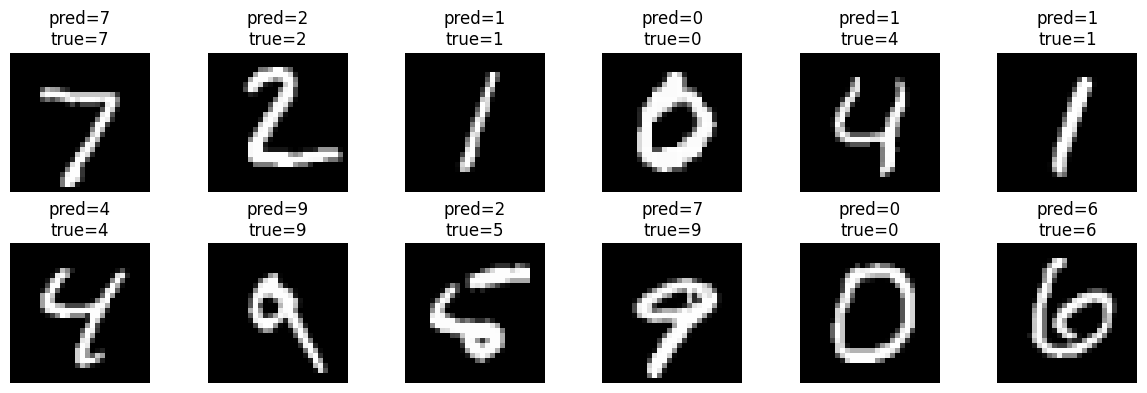

In [10]:
@torch.no_grad()
def show_predictions(model, loader, device, cfg, n=12):
    model.eval()

    x, y = next(iter(loader))
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)

    logits = model(x)
    predictions = logits.argmax(dim=-1)

    images_cpu = x.detach().cpu().reshape(-1, cfg.image_height, cfg.image_width)
    y_cpu = y.detach().cpu()
    pred_cpu = predictions.detach().cpu()

    plt.figure(figsize=(12, 4))

    for i in range(n):
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(images_cpu[i], cmap="gray")
        plt.title(f"pred={int(pred_cpu[i])}\ntrue={int(y_cpu[i])}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


model_to_show = "ParaGRU quasi-DEER accel_scan"
show_predictions(trained_models[model_to_show], test_loader, device, cfg, n=12)


## 10. Direct `ParaGRUCell` one-step example

This is the cell-level API, analogous to `torch.nn.GRUCell`.


In [11]:
cell = ParaGRUCell(
    input_size=1,
    hidden_size=128,
    dtype=torch.float32,
).to(device)

x_t = torch.randn(32, 1, device=device)
h_prev = torch.zeros(32, 128, device=device)

h_next = cell(x_t, h_prev)

print("x_t shape:", tuple(x_t.shape))
print("h_prev shape:", tuple(h_prev.shape))
print("h_next shape:", tuple(h_next.shape))


x_t shape: (32, 1)
h_prev shape: (32, 128)
h_next shape: (32, 128)


## Summary

This notebook demonstrated:

```python
from src.pararnn import ParaGRU, ParaGRUCell
```

- Each MNIST image is used as a full pixel sequence with shape `(784, 1)`.
- `ParaGRUCell` is a one-step recurrent cell.
- `ParaGRU` can run in normal sequential mode.
- `ParaGRU` can also run in quasi-DEER mode with `scan_backend="accel_scan"` and `num_iters=8`.
- A normal PyTorch `nn.GRU` model can be trained with the same loop.
- The final section compares all three models by test accuracy and elapsed training time.
